In [1]:
# Credit Risk Scorecard - Version 2
# Modern Credit Scoring with Traditional Scorecard + XGBoost + SHAP Explainability

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scorecardpy as sc
import xgboost as xgb
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

c:\Users\nanth\anaconda3\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


All libraries loaded successfully!


In [2]:
# Load German Credit Dataset
data = sc.germancredit()

# Basic overview
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
data.head()

Dataset Shape: (1000, 21)

First 5 rows:


,status_of_existing_checking_account,duration_in_month,credit_history,purpose,credit_amount,savings_account_and_bonds,present_employment_since,installment_rate_in_percentage_of_disposable_income,personal_status_and_sex,other_debtors_or_guarantors,...,property,age_in_years,other_installment_plans,housing,number_of_existing_credits_at_this_bank,job,number_of_people_being_liable_to_provide_maintenance_for,telephone,foreign_worker,creditability
0,... < 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,... >= 7 years,4,male : divorced/separated,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,good
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,male : divorced/separated,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,good
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,guarantor,...,building society savings agreement/ life insur...,45,none,for free,1,skilled employee / official,2,none,yes,good
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : divorced/separated,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,bad


In [3]:
# Fix target variable - convert 'good'/'bad' to 1/0
data['creditability'] = data['creditability'].map({'good': 0, 'bad': 1})

print("Target Variable Distribution:")
print(data['creditability'].value_counts())
print(f"\nDefault Rate: {data['creditability'].mean():.1%}")
print(f"\nTotal Records: {data.shape[0]}")
print(f"Total Features: {data.shape[1]}")
print(f"\nMissing Values: {data.isnull().sum().sum()} total missing values")

Target Variable Distribution:
creditability
0    700
1    300
Name: count, dtype: int64

Default Rate: 30.0%

Total Records: 1000
Total Features: 21

Missing Values: 0 total missing values


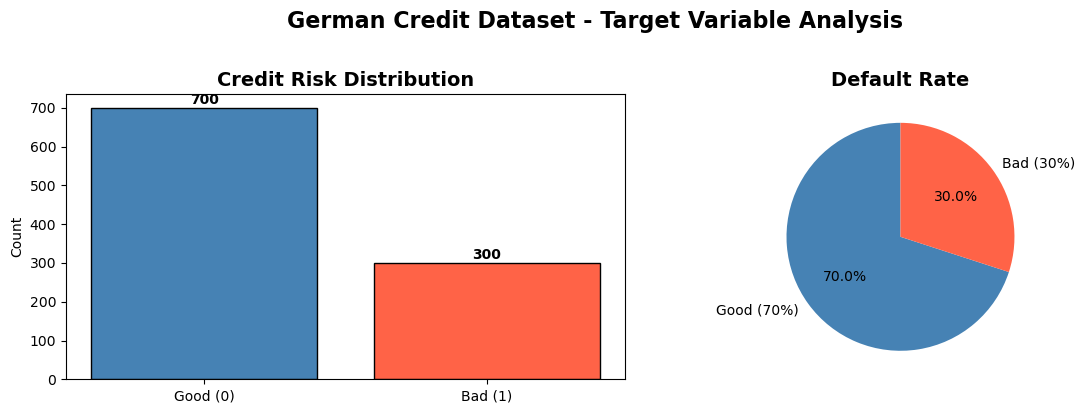

In [4]:
# EDA Visualisation - Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Good (0)', 'Bad (1)'], 
            data['creditability'].value_counts().values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Credit Risk Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(data['creditability'].value_counts().values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(data['creditability'].value_counts().values,
            labels=['Good (70%)', 'Bad (30%)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Default Rate', fontsize=14, fontweight='bold')

plt.suptitle('German Credit Dataset - Target Variable Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# WoE Binning & Information Value
bins = sc.woebin(data, y='creditability')

# Display Information Value summary
iv_summary = pd.DataFrame({
    'Variable': list(bins.keys()),
    'IV': [bins[var]['bin_iv'].sum() for var in bins.keys()]
}).sort_values('IV', ascending=False).reset_index(drop=True)

print("Information Value Summary:")
print("==========================")
print(iv_summary.to_string())
print("\nIV Interpretation:")
print("< 0.02  : Useless")
print("0.02-0.1: Weak")
print("0.1-0.3 : Medium")
print("0.3-0.5 : Strong")
print("> 0.5   : Suspicious")

[INFO] creating woe binning ...
Information Value Summary:
                                                    Variable        IV
0                        status_of_existing_checking_account  0.639372
1                                             credit_history  0.291830
2                                          duration_in_month  0.282618
3                                  savings_account_and_bonds  0.190974
4                                              credit_amount  0.181220
5                                                    purpose  0.152924
6                                               age_in_years  0.130499
7                                                   property  0.112638
8                                   present_employment_since  0.085301
9                                                    housing  0.083293
10                                   other_installment_plans  0.057592
11       installment_rate_in_percentage_of_disposable_income  0.025569
12                

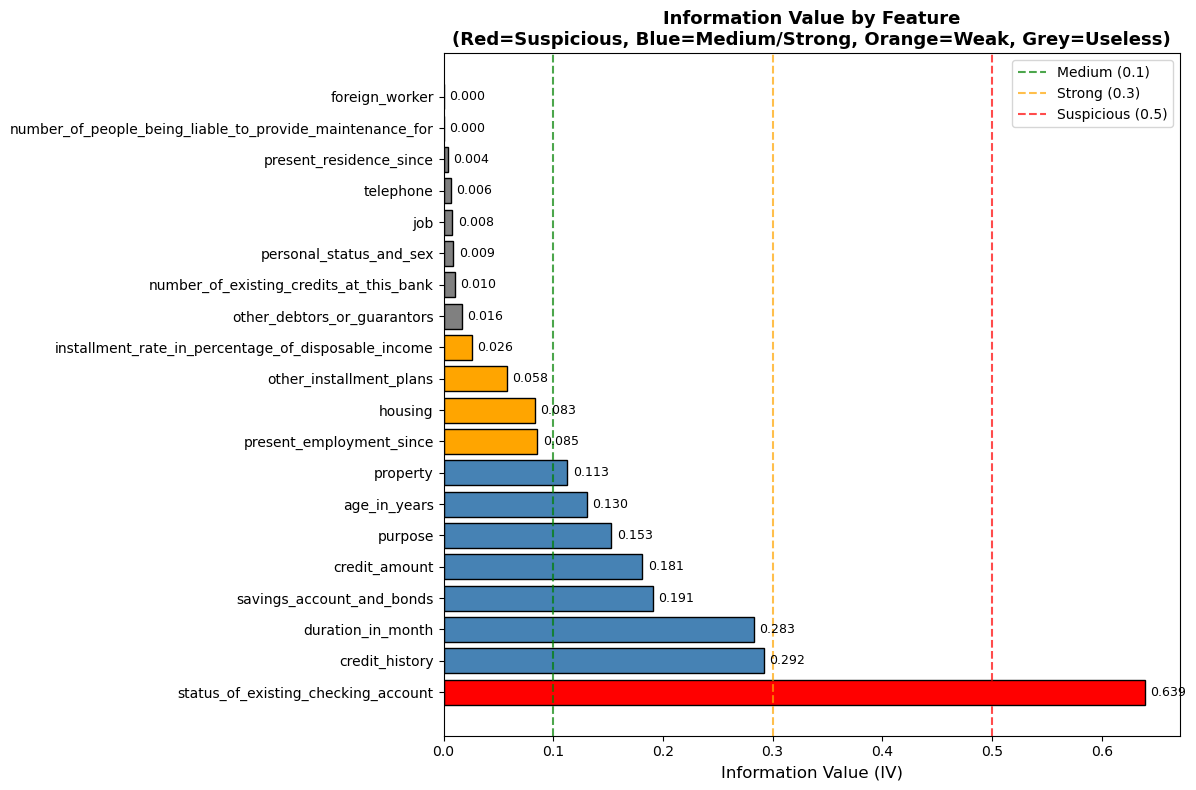

In [6]:
# IV Visualisation
plt.figure(figsize=(12, 8))
colors = ['red' if iv > 0.5 else 'steelblue' if iv >= 0.1 
          else 'orange' if iv >= 0.02 else 'grey' 
          for iv in iv_summary['IV']]

bars = plt.barh(iv_summary['Variable'], iv_summary['IV'], 
                color=colors, edgecolor='black')

# Add value labels
for bar, iv in zip(bars, iv_summary['IV']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{iv:.3f}', va='center', fontsize=9)

# Add reference lines
plt.axvline(x=0.1, color='green', linestyle='--', alpha=0.7, label='Medium (0.1)')
plt.axvline(x=0.3, color='orange', linestyle='--', alpha=0.7, label='Strong (0.3)')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Suspicious (0.5)')

plt.xlabel('Information Value (IV)', fontsize=12)
plt.title('Information Value by Feature\n(Red=Suspicious, Blue=Medium/Strong, Orange=Weak, Grey=Useless)', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Select variables with IV >= 0.02 (weak and above)
selected_vars = iv_summary[iv_summary['IV'] >= 0.02]['Variable'].tolist()
selected_vars.append('creditability')

print(f"Selected {len(selected_vars)-1} variables for modelling:")
for var in selected_vars[:-1]:
    print(f"  - {var}")

# Filter dataset to selected variables
data_selected = data[selected_vars]

# Apply WoE transformation
data_woe = sc.woebin_ply(data_selected, bins)

print(f"\nWoE transformed dataset shape: {data_woe.shape}")
print("\nFirst 3 rows of WoE transformed data:")
data_woe.head(3)

Selected 12 variables for modelling:
  - status_of_existing_checking_account
  - credit_history
  - duration_in_month
  - savings_account_and_bonds
  - credit_amount
  - purpose
  - age_in_years
  - property
  - present_employment_since
  - housing
  - other_installment_plans
  - installment_rate_in_percentage_of_disposable_income
[INFO] converting into woe values ...

WoE transformed dataset shape: (1000, 13)

First 3 rows of WoE transformed data:


,creditability,other_installment_plans_woe,installment_rate_in_percentage_of_disposable_income_woe,credit_amount_woe,credit_history_woe,status_of_existing_checking_account_woe,savings_account_and_bonds_woe,housing_woe,property_woe,duration_in_month_woe,present_employment_since_woe,age_in_years_woe,purpose_woe
0,0,-0.121179,0.157300,0.033661,-0.733741,0.614204,-0.762140,-0.194156,-0.461035,-1.312186,-0.235566,-0.212371,-0.410063
1,1,-0.121179,-0.190473,0.390539,0.088319,0.614204,0.271358,-0.194156,-0.461035,1.134980,0.032103,0.528844,-0.410063
2,0,-0.121179,-0.190473,-0.258307,-0.733741,-1.176263,0.271358,-0.194156,-0.461035,-0.346625,-0.394415,-0.212371,0.279920


In [8]:
# Train/Test Split
X = data_woe.drop('creditability', axis=1)
y = data_woe['creditability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} records")
print(f"Test set:     {X_test.shape[0]} records")
print(f"\nTrain default rate: {y_train.mean():.1%}")
print(f"Test default rate:  {y_test.mean():.1%}")

# Build Logistic Regression Model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predictions
y_pred_train = lr.predict_proba(X_train)[:, 1]
y_pred_test = lr.predict_proba(X_test)[:, 1]

# AUC Scores
train_auc = roc_auc_score(y_train, y_pred_train)
test_auc = roc_auc_score(y_test, y_pred_test)

print(f"\nLogistic Regression Results:")
print(f"============================")
print(f"Train AUC (Gini): {train_auc:.4f} ({(2*train_auc-1):.4f})")
print(f"Test AUC  (Gini): {test_auc:.4f} ({(2*test_auc-1):.4f})")

Training set: 700 records
Test set:     300 records

Train default rate: 30.0%
Test default rate:  30.0%

Logistic Regression Results:
Train AUC (Gini): 0.8184 (0.6367)
Test AUC  (Gini): 0.8239 (0.6478)


In [9]:
# Generate Scorecard Points
card = sc.scorecard(bins, lr, X_train.columns.tolist())

# Apply scorecard to get scores
train_score = sc.scorecard_ply(data_selected.iloc[X_train.index], card)
test_score = sc.scorecard_ply(data_selected.iloc[X_test.index], card)

print("Scorecard Score Distribution:")
print("==============================")
print(f"Train Score - Mean: {train_score['score'].mean():.1f}, "
      f"Std: {train_score['score'].std():.1f}, "
      f"Min: {train_score['score'].min()}, "
      f"Max: {train_score['score'].max()}")
print(f"Test Score  - Mean: {test_score['score'].mean():.1f}, "
      f"Std: {test_score['score'].std():.1f}, "
      f"Min: {test_score['score'].min()}, "
      f"Max: {test_score['score'].max()}")

Scorecard Score Distribution:
Train Score - Mean: 471.3, Std: 99.9, Min: 184.0, Max: 718.0
Test Score  - Mean: 469.7, Std: 100.3, Min: 215.0, Max: 721.0


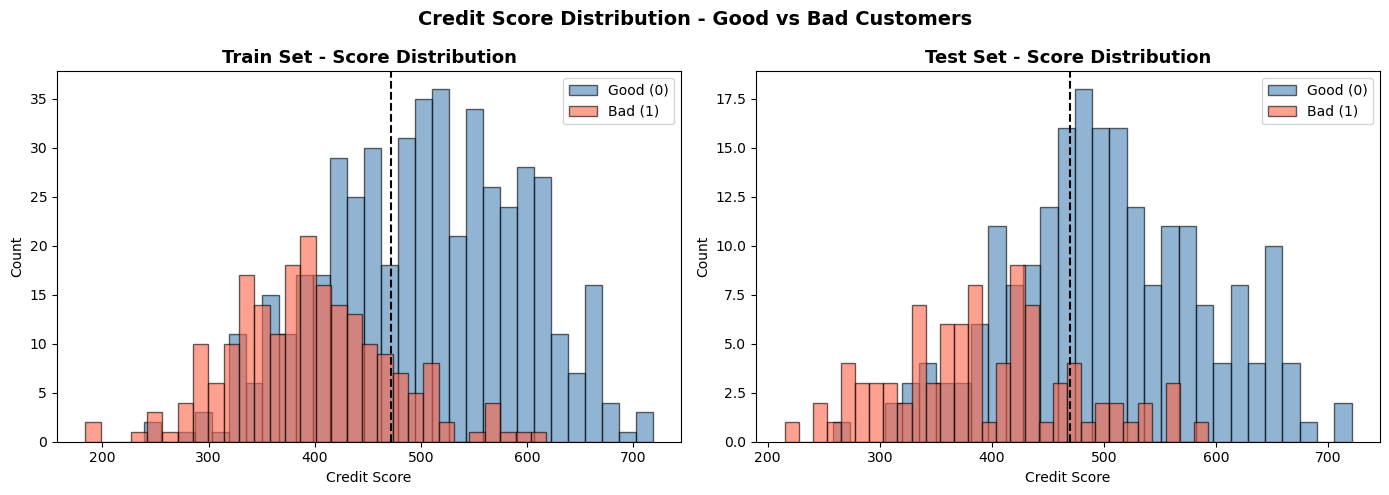

In [10]:
# Score Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Add creditability to scores for plotting
train_score['creditability'] = y_train.values
test_score['creditability'] = y_test.values

# Train score distribution
axes[0].hist(train_score[train_score['creditability']==0]['score'], 
             bins=30, alpha=0.6, color='steelblue', label='Good (0)', edgecolor='black')
axes[0].hist(train_score[train_score['creditability']==1]['score'], 
             bins=30, alpha=0.6, color='tomato', label='Bad (1)', edgecolor='black')
axes[0].set_title('Train Set - Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].axvline(x=train_score['score'].mean(), color='black', 
                linestyle='--', label='Mean Score')

# Test score distribution
axes[1].hist(test_score[test_score['creditability']==0]['score'], 
             bins=30, alpha=0.6, color='steelblue', label='Good (0)', edgecolor='black')
axes[1].hist(test_score[test_score['creditability']==1]['score'], 
             bins=30, alpha=0.6, color='tomato', label='Bad (1)', edgecolor='black')
axes[1].set_title('Test Set - Score Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].axvline(x=test_score['score'].mean(), color='black', 
                linestyle='--', label='Mean Score')

plt.suptitle('Credit Score Distribution - Good vs Bad Customers', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# XGBoost Model
# Use original data (not WoE transformed) for XGBoost
X_raw = data.drop('creditability', axis=1)
y_raw = data['creditability']

# Convert categorical variables to dummies
X_raw = pd.get_dummies(X_raw)

# Clean column names - remove special characters that XGBoost doesn't like
X_raw.columns = X_raw.columns.str.replace('[', '_', regex=False)\
                              .str.replace(']', '_', regex=False)\
                              .str.replace('<', '_', regex=False)\
                              .str.replace('>', '_', regex=False)\
                              .str.replace(' ', '_', regex=False)

# Train/test split using same random state
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw)

# Build XGBoost Model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Predictions
y_pred_train_xgb = xgb_model.predict_proba(X_train_xgb)[:, 1]
y_pred_test_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# AUC Scores
train_auc_xgb = roc_auc_score(y_train_xgb, y_pred_train_xgb)
test_auc_xgb = roc_auc_score(y_test_xgb, y_pred_test_xgb)

print(f"XGBoost Results:")
print(f"================")
print(f"Train AUC (Gini): {train_auc_xgb:.4f} ({(2*train_auc_xgb-1):.4f})")
print(f"Test AUC  (Gini): {test_auc_xgb:.4f} ({(2*test_auc_xgb-1):.4f})")

XGBoost Results:
Train AUC (Gini): 0.9890 (0.9780)
Test AUC  (Gini): 0.7683 (0.5365)


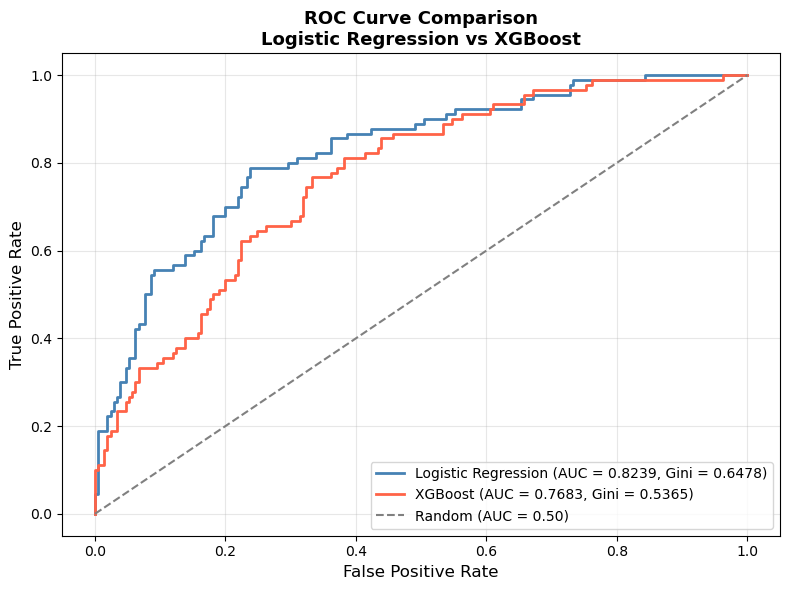

In [12]:
# ROC Curve Comparison
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_test)
ax.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
        label=f'Logistic Regression (AUC = {test_auc:.4f}, Gini = {(2*test_auc-1):.4f})')

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_xgb, y_pred_test_xgb)
ax.plot(fpr_xgb, tpr_xgb, color='tomato', lw=2,
        label=f'XGBoost (AUC = {test_auc_xgb:.4f}, Gini = {(2*test_auc_xgb-1):.4f})')

# Random line
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison\nLogistic Regression vs XGBoost', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

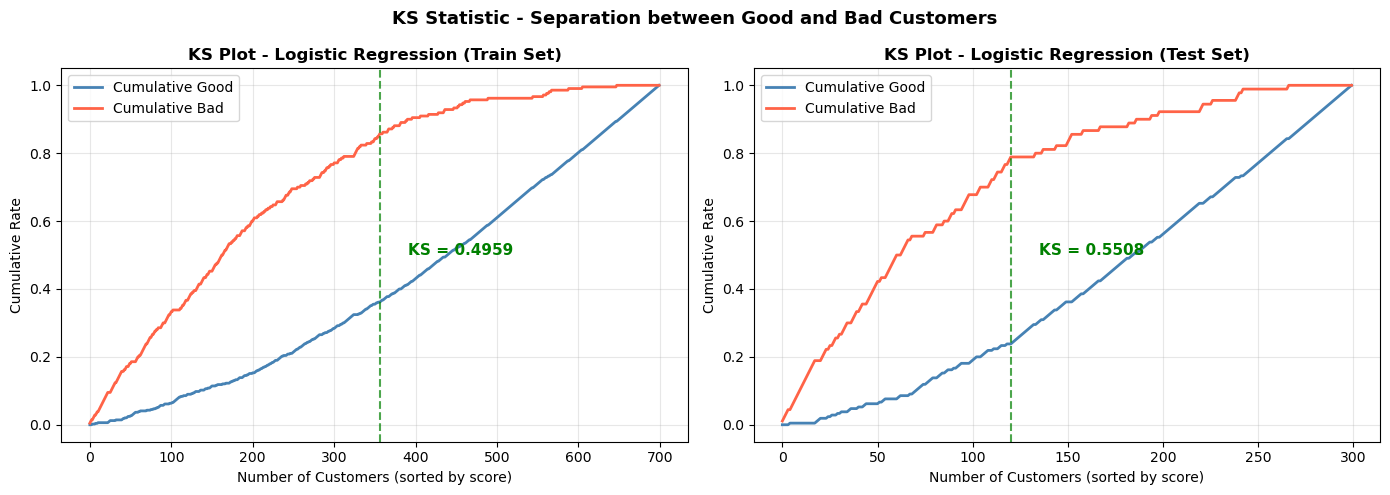

In [13]:
# KS Statistic Plot - Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Train Set', 'Test Set']
):
    # Create dataframe for KS calculation
    ks_df = pd.DataFrame({'y_true': y_true.values, 'y_pred': y_pred})
    ks_df = ks_df.sort_values('y_pred', ascending=False).reset_index(drop=True)
    
    # Calculate cumulative good and bad rates
    total_good = (ks_df['y_true'] == 0).sum()
    total_bad = (ks_df['y_true'] == 1).sum()
    
    ks_df['cum_good'] = (ks_df['y_true'] == 0).cumsum() / total_good
    ks_df['cum_bad'] = (ks_df['y_true'] == 1).cumsum() / total_bad
    ks_df['ks'] = ks_df['cum_bad'] - ks_df['cum_good']
    
    ks_stat = ks_df['ks'].max()
    ks_idx = ks_df['ks'].idxmax()
    
    # Plot
    ax.plot(range(len(ks_df)), ks_df['cum_good'], 
            color='steelblue', lw=2, label='Cumulative Good')
    ax.plot(range(len(ks_df)), ks_df['cum_bad'], 
            color='tomato', lw=2, label='Cumulative Bad')
    ax.axvline(x=ks_idx, color='green', linestyle='--', alpha=0.7)
    ax.annotate(f'KS = {ks_stat:.4f}', 
                xy=(ks_idx, ks_df['cum_bad'][ks_idx]),
                xytext=(ks_idx + len(ks_df)*0.05, 0.5),
                fontsize=11, fontweight='bold', color='green')
    
    ax.set_title(f'KS Plot - Logistic Regression ({title})', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Customers (sorted by score)')
    ax.set_ylabel('Cumulative Rate')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('KS Statistic - Separation between Good and Bad Customers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Calculating SHAP values...


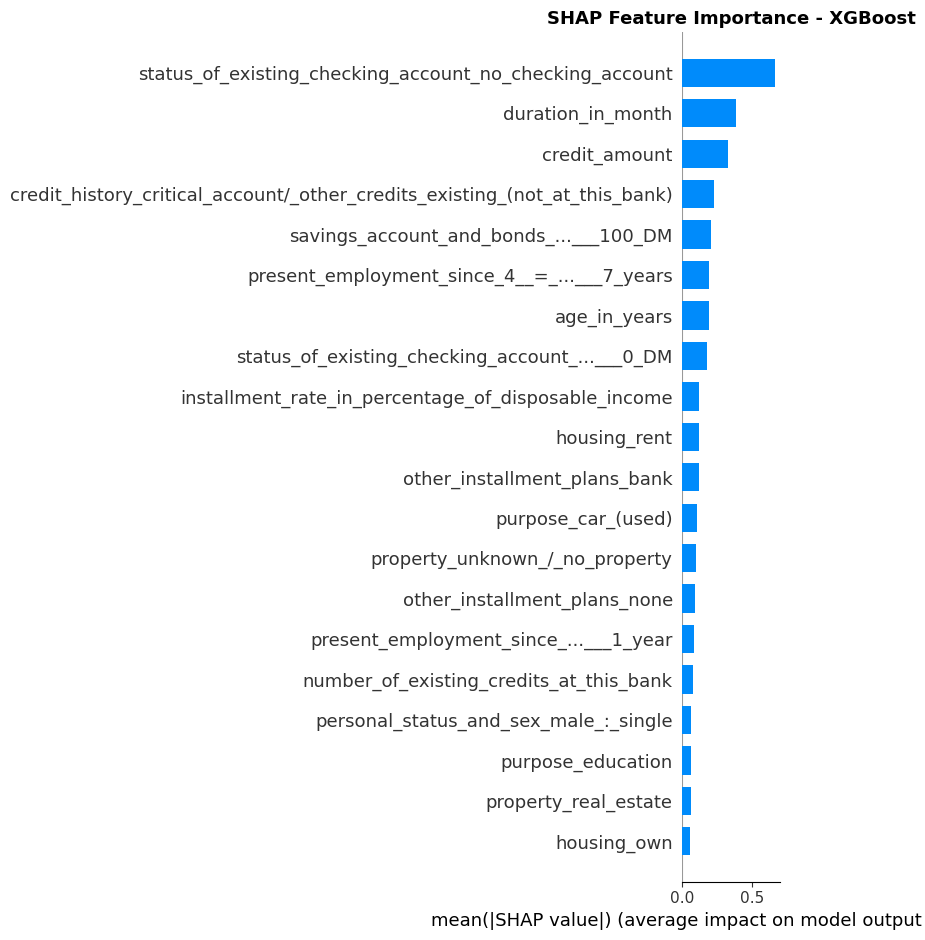

In [14]:
# SHAP Explainability - XGBoost
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb)

# Summary Plot - Feature Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_xgb, 
                  plot_type="bar", 
                  title="SHAP Feature Importance - XGBoost",
                  show=False)
plt.title('SHAP Feature Importance - XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

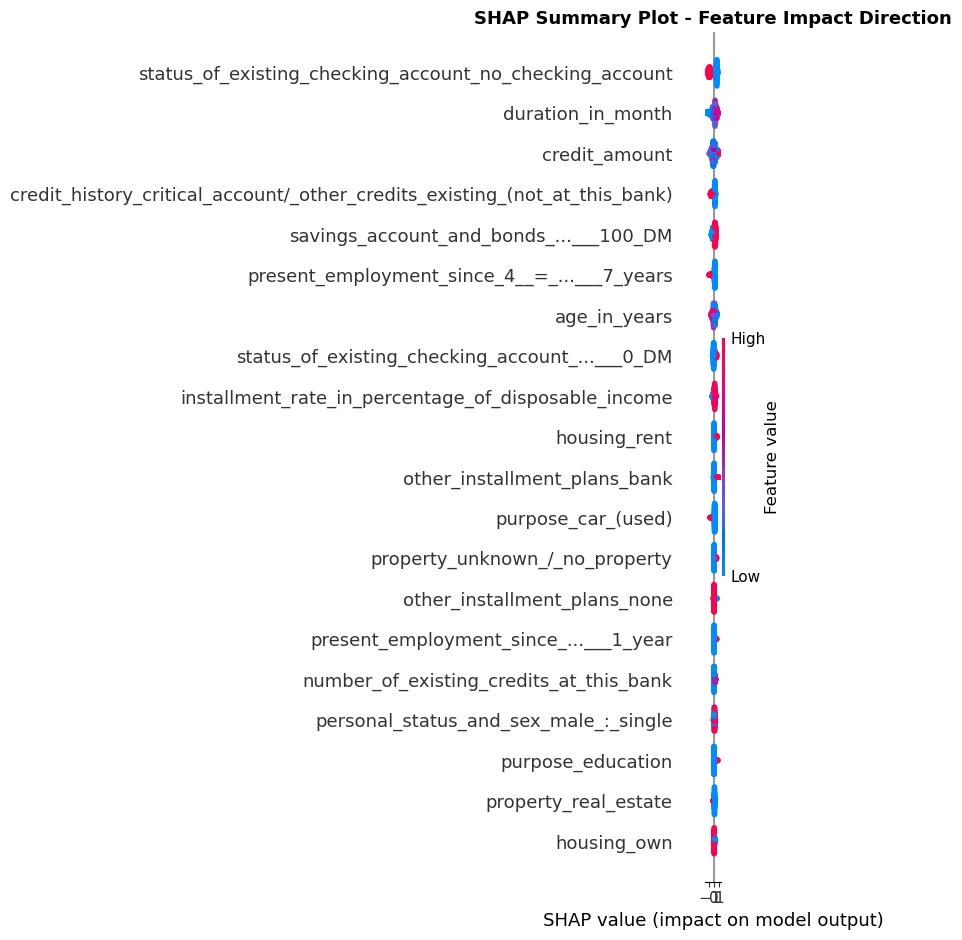

In [15]:
# SHAP Dot Plot - shows direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_xgb,
                  show=False)
plt.title('SHAP Summary Plot - Feature Impact Direction', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Model Comparison Summary
print("=" * 55)
print("        MODEL PERFORMANCE COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Metric':<25} {'Log. Regression':>15} {'XGBoost':>12}")
print("-" * 55)
print(f"{'Train AUC':<25} {train_auc:>15.4f} {train_auc_xgb:>12.4f}")
print(f"{'Test AUC':<25} {test_auc:>15.4f} {test_auc_xgb:>12.4f}")
print(f"{'Train Gini':<25} {(2*train_auc-1):>15.4f} {(2*train_auc_xgb-1):>12.4f}")
print(f"{'Test Gini':<25} {(2*test_auc-1):>15.4f} {(2*test_auc_xgb-1):>12.4f}")
print(f"{'Overfitting':<25} {'No':>15} {'Yes':>12}")
print(f"{'Interpretability':<25} {'High':>15} {'Medium':>12}")
print(f"{'Regulatory Friendly':<25} {'Yes':>15} {'Partial':>12}")
print("=" * 55)
print("""
Key Observations:
-----------------
1. Logistic Regression scorecard shows stable Gini 
   (~0.65) with no overfitting - suitable for 
   production deployment in regulated environments.

2. XGBoost overfits (Train Gini 0.98 vs Test 0.54) 
   and would need tuning via cross-validation and 
   regularisation before deployment.

3. SHAP values provide explainability for XGBoost 
   predictions - important for regulatory compliance 
   under PDPA/MAS guidelines.

4. Traditional scorecard remains preferred in credit 
   risk due to transparency and regulatory acceptance.
""")

        MODEL PERFORMANCE COMPARISON SUMMARY
Metric                    Log. Regression      XGBoost
-------------------------------------------------------
Train AUC                          0.8184       0.9890
Test AUC                           0.8239       0.7683
Train Gini                         0.6367       0.9780
Test Gini                          0.6478       0.5365
Overfitting                            No          Yes
Interpretability                     High       Medium
Regulatory Friendly                   Yes      Partial

Key Observations:
-----------------
1. Logistic Regression scorecard shows stable Gini 
   (~0.65) with no overfitting - suitable for 
   production deployment in regulated environments.

2. XGBoost overfits (Train Gini 0.98 vs Test 0.54) 
   and would need tuning via cross-validation and 
   regularisation before deployment.

3. SHAP values provide explainability for XGBoost 
   predictions - important for regulatory compliance 
   under PDPA/MAS guidel